In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('Social_Network_ADs.csv')

In [7]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


In [9]:
#ip= age & estimate variable
x=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [11]:
x.describe()

,Age,EstimatedSalary
count,400.000000,400.000000
mean,37.655000,69742.500000
std,10.482877,34096.960282
min,18.000000,15000.000000
25%,29.750000,43000.000000
50%,37.000000,70000.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


## Do Normalisation

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
scaler=MinMaxScaler()

In [18]:
x_scaled=scaler.fit_transform(x)

In [20]:
x_scaled

array([[0.02380952, 0.02962963],
       [0.4047619 , 0.03703704],
       [0.19047619, 0.20740741],
       [0.21428571, 0.31111111],
       [0.02380952, 0.45185185],
       [0.21428571, 0.31851852],
       [0.21428571, 0.51111111],
       [0.33333333, 1.        ],
       [0.16666667, 0.13333333],
       [0.4047619 , 0.37037037],
       [0.19047619, 0.48148148],
       [0.19047619, 0.27407407],
       [0.04761905, 0.52592593],
       [0.33333333, 0.02222222],
       [0.        , 0.4962963 ],
       [0.26190476, 0.48148148],
       [0.69047619, 0.07407407],
       [0.64285714, 0.08148148],
       [0.66666667, 0.0962963 ],
       [0.71428571, 0.1037037 ],
       [0.64285714, 0.05185185],
       [0.69047619, 0.25185185],
       [0.71428571, 0.19259259],
       [0.64285714, 0.05185185],
       [0.66666667, 0.05925926],
       [0.69047619, 0.03703704],
       [0.73809524, 0.0962963 ],
       [0.69047619, 0.11111111],
       [0.26190476, 0.20740741],
       [0.30952381, 0.02222222],
       [0.

In [22]:
pd.DataFrame(x_scaled).describe()

,0,1
count,400.000000,400.000000
mean,0.467976,0.405500
std,0.249592,0.252570
min,0.000000,0.000000
25%,0.279762,0.207407
50%,0.452381,0.407407
75%,0.666667,0.540741
max,1.000000,1.000000


In [24]:
#purchased data count
y.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

<Axes: xlabel='Purchased', ylabel='count'>

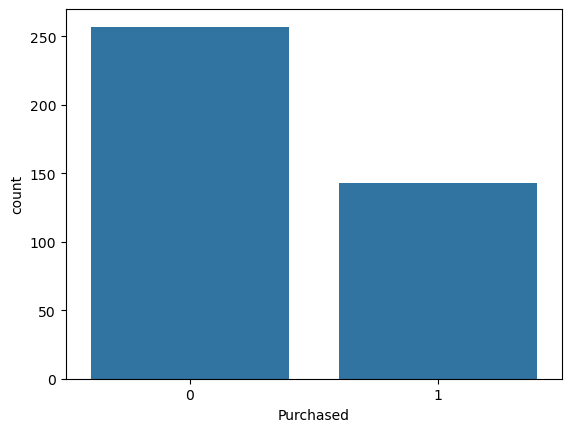

In [26]:
sns.countplot(x=y)

## Cross validation

In [29]:
from sklearn.model_selection import train_test_split

In [37]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,random_state=0)

## BUILD OUR MODEL (LINEAR)

In [40]:
from sklearn.linear_model import LogisticRegression


In [44]:
log=LogisticRegression()

In [46]:
log.fit(x_train,y_train)

LogisticRegression()

In [50]:
log.score(x_train,y_train)

0.8033333333333333

In [52]:
log.score(x_test,y_test)

0.89

In [54]:
y_pred=log.predict(x_test)

In [60]:
result=pd.DataFrame({'actual':y_test,'Predicted':y_pred})
result

,actual,Predicted
132,0,0
309,0,0
341,0,0
196,0,0
246,0,0
...,...,...
146,1,0
135,0,0
390,1,0
264,1,1


In [66]:
## different evaluation method than linear regression
from sklearn.metrics import ConfusionMatrixDisplay

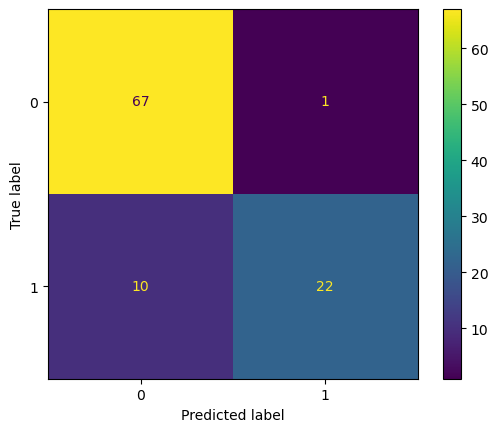

In [70]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
#0=purchased and 1=not purchased

In [72]:
from sklearn.metrics import classification_report

In [76]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.99      0.92        68
           1       0.96      0.69      0.80        32

    accuracy                           0.89       100
   macro avg       0.91      0.84      0.86       100
weighted avg       0.90      0.89      0.88       100



In [78]:
#actual accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.89

## predict

In [81]:
new1=[[31,45000]]

In [91]:
#dont fit_trnsorm, as it will change min max values, only use transform
new_scaled=scaler.transform(new1)

In [93]:
log.predict(new_scaled)

array([0], dtype=int64)